In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import correlate
from PIL import Image, ImageDraw
import math

# Создаём изображение чёрного пятиугольника на белом фоне (аналог Paint)
# size = 200
# img = Image.new('L', (size, size), 255)
# draw = ImageDraw.Draw(img)
#
# cx, cy, r = 100, 105, 70
# points = []
# for i in range(5):
#     angle = math.radians(-90 + i * 72)
#     points.append((cx + r * math.cos(angle), cy + r * math.sin(angle)))
# draw.polygon(points, fill=0)
#
# img.save('pentagon.png')
# plt.imshow(img, cmap='gray')
# plt.title('Созданное изображение пятиугольника')
# plt.axis('off')
# plt.show()

Часть 1. Поиск границ

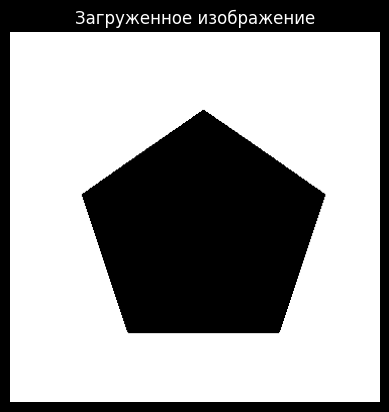

Размер матрицы: (366, 366)


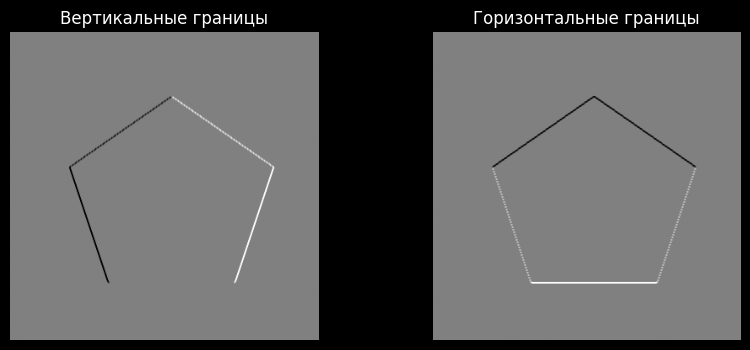

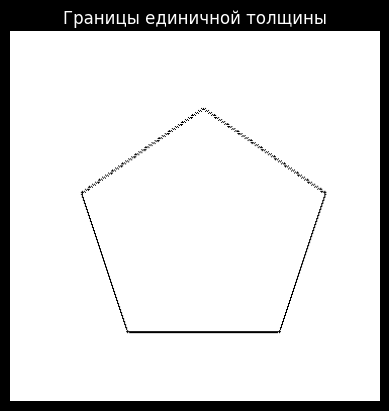

In [60]:
# --- Загрузка изображения (аналог imread) ---
A = np.array(Image.open('pentagon.bmp'))

# Если изображение цветное — переводим в серое (аналог rgb2gray)
if A.ndim == 3:
    A = np.dot(A[..., :3], [0.2989, 0.5870, 0.1140])

plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Загруженное изображение')
plt.axis('off')
plt.show()

print(f'Размер матрицы: {A.shape}')

# --- Перевод в формат double (аналог im2double) ---
A = A.astype(np.float64) / 255.0

# --- Маска фильтра Собела (аналог задания Sx, Sy) ---
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float64)
Sy = Sx.T  # транспонирование (аналог Sx')

# --- Производные (аналог imfilter) ---
# correlate — корреляция, как imfilter в MATLAB по умолчанию
Dx = correlate(A, Sx)   # Производная по х → вертикальные границы
Dy = correlate(A, Sy)   # Производная по у → горизонтальные границы

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(Dx, cmap='gray')
axes[0].set_title('Вертикальные границы')
axes[0].axis('off')
axes[1].imshow(Dy, cmap='gray')
axes[1].set_title('Горизонтальные границы')
axes[1].axis('off')
plt.show()

# --- Функция edge (аналог edge(A) из методички) ---
# Включает: Собел + модуль градиента + немаксимальное подавление + порог

def edge_custom(img):
    """
    Аналог MATLAB edge(A).
    Реализация по методичке:
      1) Фильтр Собела
      2) Модуль градиента
      3) Немаксимальное подавление (по направлению градиента)
      4) Пороговая бинаризация
    """
    Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Sy = Sx.T

    Dx = correlate(img, Sx)
    Dy = correlate(img, Sy)

    mag = np.sqrt(Dx**2 + Dy**2)
    ang = np.degrees(np.arctan2(Dy, Dx)) % 180  # 0..180

    h, w = mag.shape
    nms = np.zeros_like(mag)

    # Немаксимальное подавление (алгоритм из теоретической части методички)
    for y in range(2, h - 2):
        for x in range(2, w - 2):
            a = ang[y, x]

            # Квантование направления градиента на 4 сектора
            if (a < 22.5) or (a >= 157.5):
                n1, n2 = mag[y, x - 1], mag[y, x + 1]
            elif 22.5 <= a < 67.5:
                n1, n2 = mag[y - 1, x + 1], mag[y + 1, x - 1]
            elif 67.5 <= a < 112.5:
                n1, n2 = mag[y - 1, x], mag[y + 1, x]
            else:
                n1, n2 = mag[y - 1, x - 1], mag[y + 1, x + 1]

            # Условие из методички: оставляем, если текущая >= соседей
            if mag[y, x] >= n1 and mag[y, x] >= n2:
                nms[y, x] = mag[y, x]

    # Пороговая бинаризация
    threshold = 0.10 * nms.max()
    E = (nms > threshold).astype(np.uint8)
    return E

E = edge_custom(A)

plt.figure()
plt.imshow(1 - E, cmap='gray')
plt.title('Границы единичной толщины')
plt.axis('off')
plt.show()

Часть 2. Поиск прямых с помощью преобразования Хафа (стандартная форма y = kx + b)

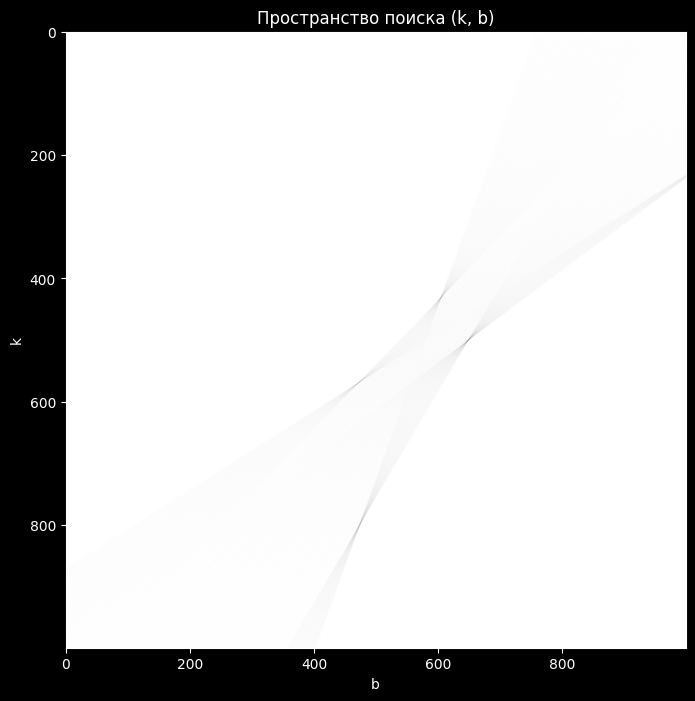

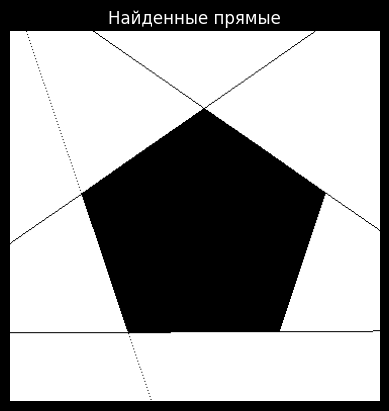

In [61]:
# --- Пространство поиска (аналог H=zeros(KMAX,BMAX)) ---
KMAX = 1000
BMAX = 1000
H = np.zeros((KMAX, BMAX), dtype=np.float64)

# Ограничения на параметры прямых
kmax = 5.0
bmax = 1000.0

h_img, w_img = E.shape

# --- Преобразование Хафа (алгоритм из методички, часть 2) ---
for x in range(w_img):
    for y in range(h_img):
        if E[y, x] == 1:
            for KI in range(KMAX):
                k = KI * (2 * kmax) / (KMAX - 1) - kmax
                b = -(x + 1) * k + (y + 1)   # +1 для соответствия 1-based MATLAB
                BI = int(round((b + bmax) * (BMAX - 1) / (2 * bmax) + 1)) - 1  # → 0-based
                if 0 <= BI < BMAX:
                    H[KI, BI] += 1

plt.figure(figsize=(8, 8))
plt.imshow(-H, cmap='gray', aspect='auto')
plt.title('Пространство поиска (k, b)')
plt.xlabel('b')
plt.ylabel('k')
plt.show()

# --- Отрисовка найденных прямых (4 прохода, как в методичке) ---
A_draw = A.copy()

for Pass in range(4):
    # Ищем максимальный отклик (аналог max(H(:)), find)
    Hbest = H.max()
    idx = np.argwhere(H == Hbest)[0]
    KIbest, BIbest = idx[0], idx[1]

    # Пересчёт индексов в параметры (формулы из методички)
    kbest = KIbest * (2 * kmax) / (KMAX - 1) - kmax
    bbest = BIbest * (2 * bmax) / (BMAX - 1) - bmax

    # Рисуем прямую (перебор x, вычисление y = k*x + b)
    for x in range(w_img):
        y = int(round(kbest * (x + 1) + bbest)) - 1  # обратно в 0-based
        if 0 <= y < h_img:
            A_draw[y, x] = 0

    # Удаляем область максимума (заплатка, как в методичке)
    d = 5
    r1 = max(0, KIbest - d)
    r2 = min(KMAX, KIbest + d + 1)
    c1 = max(0, BIbest - d)
    c2 = min(BMAX, BIbest + d + 1)
    H[r1:r2, c1:c2] = 0

plt.figure()
plt.imshow(A_draw, cmap='gray')
plt.title('Найденные прямые')
plt.axis('off')
plt.show()

Часть 3. Поиск прямых в нормальной форме (ρ = x·cos φ + y·sin φ)

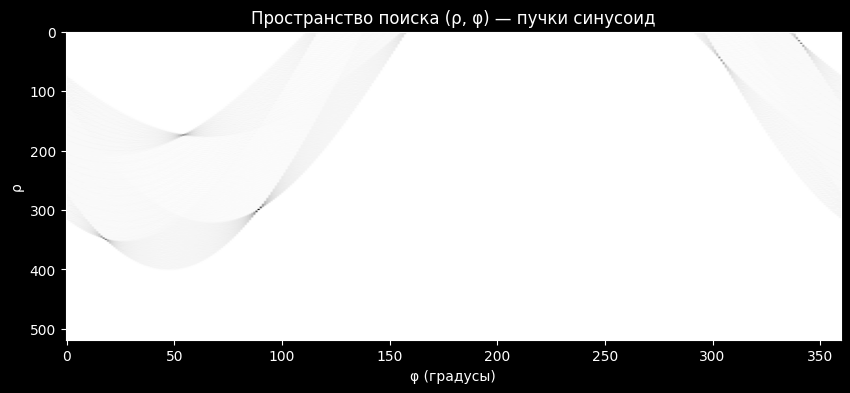

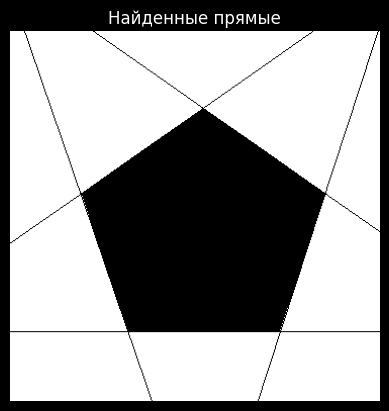

In [62]:
# --- Новое дуальное пространство <ρ, φ> ---
h_img, w_img = E.shape
RMAX = int(round(math.sqrt(w_img**2 + h_img**2))) + 1
FMAX = 360
H = np.zeros((RMAX, FMAX), dtype=np.float64)

# Предвычисление синусов и косинусов (как рекомендуется в методичке)
phi_arr = np.arange(1, 361)              # 1..360 градусов
cos_table = np.cos(np.radians(phi_arr))
sin_table = np.sin(np.radians(phi_arr))

# --- Преобразование Хафа в нормальной форме ---
for x in range(w_img):
    for y in range(h_img):
        if E[y, x] == 1:
            # ρ = x·cos φ + y·sin φ  (векторизовано по φ для скорости)
            ro_arr = (x + 1) * cos_table + (y + 1) * sin_table
            R_arr = np.round(ro_arr).astype(int)  # индекс = round(ρ) + 1 - 1 = round(ρ)
            for fi in range(FMAX):
                R = R_arr[fi]
                if 0 <= R < RMAX:
                    H[R, fi] += 1

plt.figure(figsize=(10, 4))
plt.imshow(-H, cmap='gray', aspect='auto')
plt.title('Пространство поиска (ρ, φ) — пучки синусоид')
plt.xlabel('φ (градусы)')
plt.ylabel('ρ')
plt.show()

# --- Отрисовка 5 найденных прямых ---
A_draw = A.copy()

for pas in range(5):
    Hmax = H.max()
    idx = np.argwhere(H == Hmax)[0]
    Rbest, Fbest = idx[0], idx[1]
    ro = Rbest  # ρ = R - 1 + 1 → Rbest (т.к. индекс уже = round(ρ))

    f_deg = Fbest + 1  # обратно в 1..360
    sf = math.sin(math.radians(f_deg))
    cf = math.cos(math.radians(f_deg))

    if abs(sf) > 1 / math.sqrt(2):
        # Горизонтальные линии: перебор x, вычисление y
        for x in range(w_img):
            y = int(round((ro - (x + 1) * cf) / sf)) - 1
            if 0 <= y < h_img:
                A_draw[y, x] = 0
    else:
        # Вертикальные линии: перебор y, вычисление x
        for y in range(h_img):
            x = int(round((ro - (y + 1) * sf) / cf)) - 1
            if 0 <= x < w_img:
                A_draw[y, x] = 0

    # Удаляем область максимума
    d = 5
    r1 = max(0, Rbest - d)
    r2 = min(RMAX, Rbest + d + 1)
    c1 = max(0, Fbest - d)
    c2 = min(FMAX, Fbest + 5 + 1)  # как в методичке: Fbest+5
    H[r1:r2, c1:c2] = 0

plt.figure()
plt.imshow(A_draw, cmap='gray')
plt.title('Найденные прямые')
plt.axis('off')
plt.show()

Часть 4. Поиск отрезков

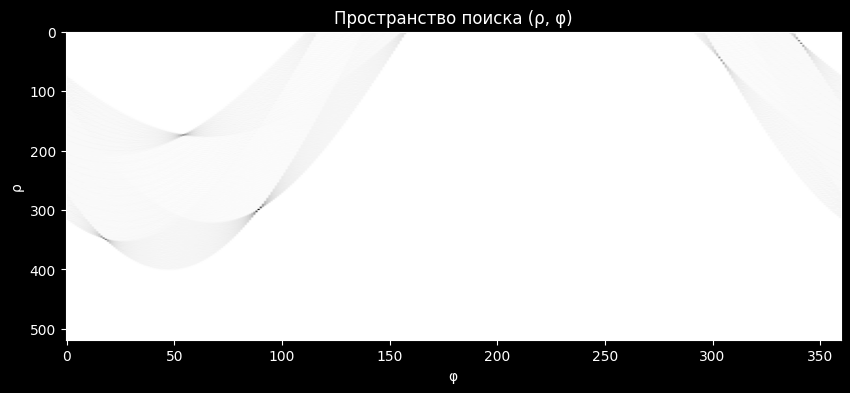

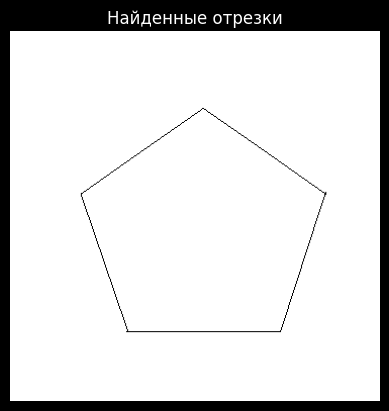

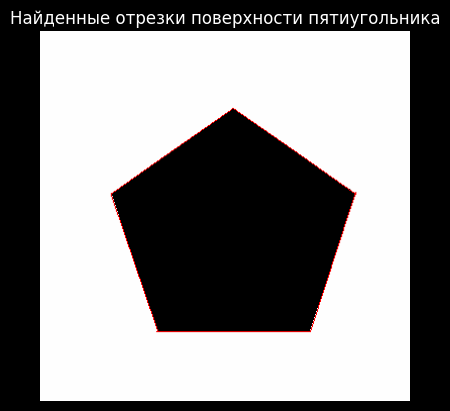

In [63]:
# --- Расширенное пространство поиска ---
h_img, w_img = E.shape
RMAX = int(round(math.sqrt(w_img**2 + h_img**2))) + 1
FMAX = 360

H = np.zeros((RMAX, FMAX), dtype=np.float64)

# Плоскости для накопления крайних координат (аналог Xmin, Ymin, Xmax, Ymax)
Xmin = np.full((RMAX, FMAX), w_img + 1, dtype=np.int32)
Ymin = np.full((RMAX, FMAX), h_img + 1, dtype=np.int32)
Xmax = np.zeros((RMAX, FMAX), dtype=np.int32)
Ymax = np.zeros((RMAX, FMAX), dtype=np.int32)

# Предвычисленные таблицы
phi_arr = np.arange(1, 361)
cos_table = np.cos(np.radians(phi_arr))
sin_table = np.sin(np.radians(phi_arr))

# --- Преобразование Хафа с накоплением крайних точек ---
for x in range(w_img):
    for y in range(h_img):
        if E[y, x] == 1:
            ro_arr = (x + 1) * cos_table + (y + 1) * sin_table
            R_arr = np.round(ro_arr).astype(int)
            for fi in range(FMAX):
                R = R_arr[fi]
                if 0 <= R < RMAX:
                    H[R, fi] += 1
                    # Накопление мин/макс координат (как в методичке)
                    if x < Xmin[R, fi]:
                        Xmin[R, fi] = x
                    if x > Xmax[R, fi]:
                        Xmax[R, fi] = x
                    if y < Ymin[R, fi]:
                        Ymin[R, fi] = y
                    if y > Ymax[R, fi]:
                        Ymax[R, fi] = y

plt.figure(figsize=(10, 4))
plt.imshow(-H, cmap='gray', aspect='auto')
plt.title('Пространство поиска (ρ, φ)')
plt.xlabel('φ')
plt.ylabel('ρ')
plt.show()

# --- Отрисовка отрезков на вспомогательном изображении ---
B = np.ones_like(A, dtype=np.float64) * 255  # белое вспомогательное изображение

for pas in range(5):
    Hmax = H.max()
    idx = np.argwhere(H == Hmax)[0]
    Rbest, Fbest = idx[0], idx[1]
    ro = Rbest

    f_deg = Fbest + 1
    sf = math.sin(math.radians(f_deg))
    cf = math.cos(math.radians(f_deg))

    if abs(sf) > 1 / math.sqrt(2):
        # Перебор x от Xmin до Xmax (как в методичке)
        x_start = Xmin[Rbest, Fbest]
        x_end = Xmax[Rbest, Fbest]
        for x in range(x_start, x_end + 1):
            y = int(round((ro - (x + 1) * cf) / sf)) - 1
            if 0 <= y < h_img:
                B[y, x] = 0
    else:
        # Перебор y от Ymin до Ymax
        y_start = Ymin[Rbest, Fbest]
        y_end = Ymax[Rbest, Fbest]
        for y in range(y_start, y_end + 1):
            x = int(round((ro - (y + 1) * sf) / cf)) - 1
            if 0 <= x < w_img:
                B[y, x] = 0

    # Удаляем область максимума
    d = 5
    r1 = max(0, Rbest - d)
    r2 = min(RMAX, Rbest + d + 1)
    c1 = max(0, Fbest - d)
    c2 = min(FMAX, Fbest + 5 + 1)
    H[r1:r2, c1:c2] = 0

plt.figure()
plt.imshow(B, cmap='gray')
plt.title('Найденные отрезки')
plt.axis('off')
plt.show()

# --- Отображение отрезков красным цветом поверх пятиугольника ---
# Аналог MATLAB: R=bitor(A,imcomplement(B)); G=bitand(A,B); B=bitand(A,B); C=cat(3,R,G,B)

A_u8 = (A * 255).astype(np.uint8)
B_u8 = B.astype(np.uint8)

R_ch = np.bitwise_or(A_u8, np.bitwise_xor(B_u8, 255))   # bitor(A, imcomplement(B))
G_ch = np.bitwise_and(A_u8, B_u8)                        # bitand(A, B)
B_ch = np.bitwise_and(A_u8, B_u8)                        # bitand(A, B)

C = np.stack([R_ch, G_ch, B_ch], axis=-1)                 # cat(3, R, G, B)

plt.figure()
plt.imshow(C)
plt.title('Найденные отрезки поверхности пятиугольника')
plt.axis('off')
plt.show()